 ### Setup & Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Styling setup
plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)
os.makedirs('screenshots', exist_ok=True)

### Day 1 — Data Ingestion & Inspection

=== DATASET PREVIEW ===
  Property_ID  Area  Bedrooms  Bathrooms  Age     Location Property_Type  \
0    PROP0001  3712         4          3   36        Rural         House   
1    PROP0002  1591         4          1   35       Suburb         House   
2    PROP0003  1646         4          3   20        Rural         Villa   
3    PROP0004  4814         1          2   13  City Center         Villa   
4    PROP0005   800         4          2   38       Suburb     Apartment   

      Price  
0  22260000  
1  16057500  
2  12730000  
3  50840000  
4  10650000  

=== DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Property_ID    300 non-null    object
 1   Area           300 non-null    int64 
 2   Bedrooms       300 non-null    int64 
 3   Bathrooms      300 non-null    int64 
 4   Age            300 non-null    int64 
 5   Loc

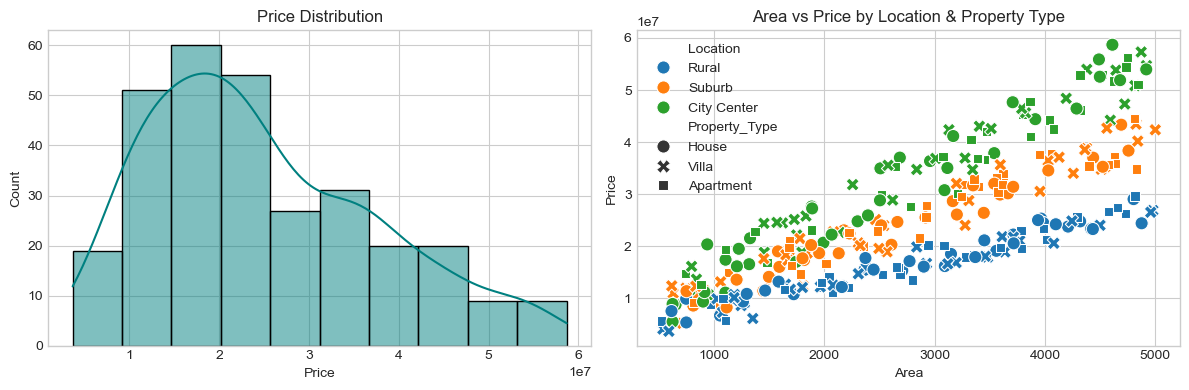

In [3]:
# Load exact dataset
df = pd.read_csv('house_prices.csv')

print("=== DATASET PREVIEW ===")
print(df.head())

print("\n=== DATASET INFO ===")
print(df.info())

print("\n=== MISSING VALUES CHECK ===")
print(df.isnull().sum())

print("\n=== SUMMARY STATISTICS ===")
print(df.describe())

# EDA Visualization
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['Price'], kde=True, color='teal')
plt.title('Price Distribution')

plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='Area', y='Price', hue='Location', style='Property_Type', s=90)
plt.title('Area vs Price by Location & Property Type')
plt.tight_layout()
plt.savefig('eda_plots.png')
plt.show()

### Day 2 — Feature Engineering & Train-Test Split

In [4]:
# Drop non-predictive identifier column and split X/y
X = df.drop(columns=['Property_ID', 'Price'])
y = df['Price']

categorical_features = ['Location', 'Property_Type']
numerical_features = ['Area', 'Bedrooms', 'Bathrooms', 'Age']

# 80/20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ]
)

# Fit & Transform
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

# Capture transformed feature names
encoded_cat_names = list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features))
all_feature_names = numerical_features + encoded_cat_names

### Day 3 — Linear Regression From Scratch (Gradient Descent)

In [5]:
class ScratchLinearRegression:
    def __init__(self, lr=0.01, epochs=1000):
        self.lr = lr
        self.epochs = epochs
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        y_vec = y.values if isinstance(y, pd.Series) else y

        for _ in range(self.epochs):
            y_pred = np.dot(X, self.weights) + self.bias
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y_vec))
            db = (1 / n_samples) * np.sum(y_pred - y_vec)
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

# Fit scratch model on numerical features
scratch_model = ScratchLinearRegression(lr=0.01, epochs=1000)
scratch_model.fit(X_train_prep[:, :len(numerical_features)], y_train)
scratch_preds = scratch_model.predict(X_test_prep[:, :len(numerical_features)])

print("--- SCRATCH MODEL PERFORMANCE ---")
print(f"Scratch Model MAE: ${mean_absolute_error(y_test, scratch_preds):,.2f}")

--- SCRATCH MODEL PERFORMANCE ---
Scratch Model MAE: $5,957,921.26


### Days 4 & 5 — Scikit-Learn Model Training & Evaluation

=== SCIKIT-LEARN LINEAR REGRESSION METRICS ===
MAE:  $2,188,736.34
MSE:  $8,454,330,868,276.75
RMSE: $2,907,633.21
R² Score: 0.9406


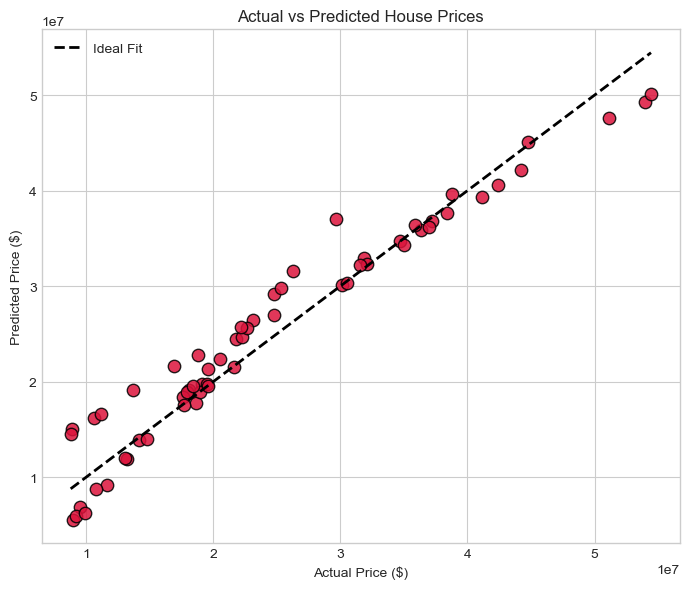

In [6]:
# Train Baseline Model
sk_model = LinearRegression()
sk_model.fit(X_train_prep, y_train)
sk_preds = sk_model.predict(X_test_prep)

# Calculate Metric Standards
mae = mean_absolute_error(y_test, sk_preds)
mse = mean_squared_error(y_test, sk_preds)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, sk_preds)

print("=== SCIKIT-LEARN LINEAR REGRESSION METRICS ===")
print(f"MAE:  ${mae:,.2f}")
print(f"MSE:  ${mse:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"R² Score: {r2:.4f}")

# Save Plot (Requirement: predictions_vs_actual.png)
plt.figure(figsize=(7, 6))
plt.scatter(y_test, sk_preds, alpha=0.85, color='crimson', edgecolors='k', s=80)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Ideal Fit')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Actual vs Predicted House Prices')
plt.legend()
plt.tight_layout()
plt.savefig('predictions_vs_actual.png')
plt.show()

### Day 6 — Model Improvement & Comparison

In [7]:
models = {
    'Linear Regression': LinearRegression(),
    'Polynomial Regression (Deg 2)': Pipeline([
        ('poly', PolynomialFeatures(degree=2)),
        ('linear', LinearRegression())
    ]),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train_prep, y_train)
    preds = model.predict(X_test_prep)
    
    m_mae = mean_absolute_error(y_test, preds)
    m_rmse = np.sqrt(mean_squared_error(y_test, preds))
    m_r2 = r2_score(y_test, preds)
    
    # 2-fold cross-validation given small sample size
    cv_score = cross_val_score(model, X_train_prep, y_train, cv=2, scoring='r2').mean()
    
    results.append({
        'Model': name,
        'MAE ($)': round(m_mae, 2),
        'RMSE ($)': round(m_rmse, 2),
        'Test R²': round(m_r2, 4),
        'CV R² Score': round(cv_score, 4)
    })

results_df = pd.DataFrame(results)
print("=== MULTI-MODEL BENCHMARK ===")
print(results_df.to_string(index=False))

=== MULTI-MODEL BENCHMARK ===
                        Model    MAE ($)   RMSE ($)  Test R²  CV R² Score
            Linear Regression 2188736.34 2907633.21   0.9406       0.9429
Polynomial Regression (Deg 2)       0.00       0.00   1.0000       1.0000
                Decision Tree 2360750.00 3109638.61   0.9321       0.9156
                Random Forest 1496187.08 2043359.47   0.9707       0.9557


### Day 7 — Feature Importance & Insights

C:\Users\binis\AppData\Local\Temp\ipykernel_52336\459167419.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')


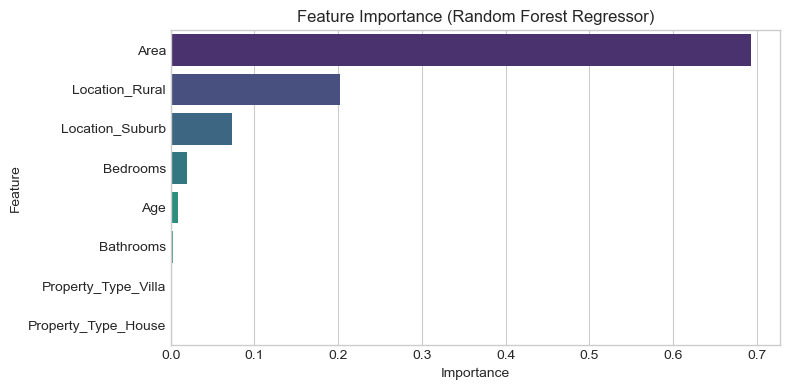

=== FEATURE IMPORTANCE RANKING ===
            Feature  Importance
               Area    0.693187
     Location_Rural    0.201724
    Location_Suburb    0.073616
           Bedrooms    0.019140
                Age    0.008199
          Bathrooms    0.002207
Property_Type_Villa    0.001143
Property_Type_House    0.000783


In [8]:
rf_model = models['Random Forest']
importances = rf_model.feature_importances_

feature_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')
plt.title('Feature Importance (Random Forest Regressor)')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

print("=== FEATURE IMPORTANCE RANKING ===")
print(feature_df.to_string(index=False))